## Title: Medical Insurance Charges Prediction 
### Machine Learning Project 

### Import the Libraries 

Lets Start the project by importing all the libraries that we will need in this project. 


In [21]:
# Imports Libraries 

# 1. To handle the data 
import numpy as np 
import pandas as pd

# 2. To Visualize the Dataset 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px


# 3. Preprocessing and Evaluation 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.datasets import make_regression

# 4. Models 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

# Load the Data from csv file
df = pd.read_csv(r"C:\Users\HP\Desktop\My AI Course practice\Machine Learning Project\Section1-Question1-InsurranceData.csv")

# Print first 5 rows from the DataFrame 
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Exploring no. of rows and columns
print("df.shape : ", df.shape)

(1338, 7)

In [46]:
# Exploring the DataType of Each Column 
print("df.info(): ", df.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
df.info():  None


In [75]:
corr = df[['age', 'charges']].corr()
print("Correlation : ", corr)

Correlation :                age   charges
age      1.000000  0.299008
charges  0.299008  1.000000


In [44]:
# Exploring Statistical approaches 
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Exploratory Data Analysis (EDA)

### Lets Explore Distribution of Charges using different Approaches ...


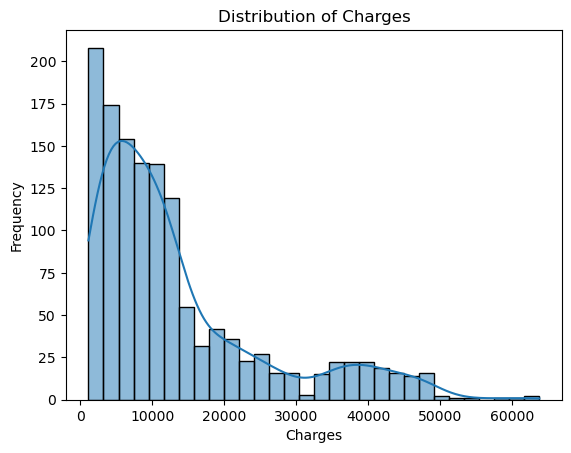

In [49]:
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

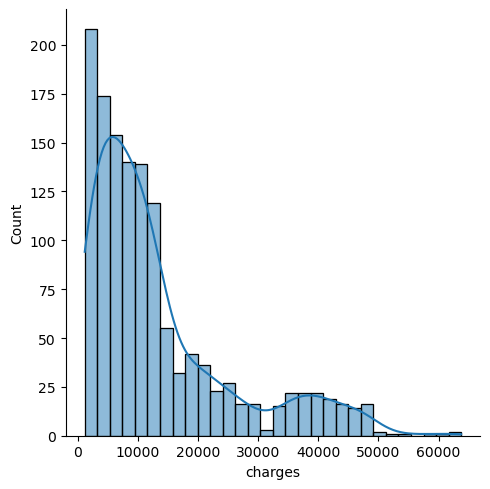

In [50]:
# Appling Distribution Plot 

sns.displot(df['charges'], kde=True)


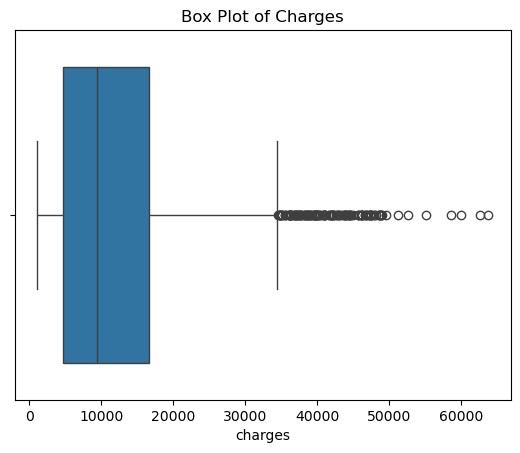

In [53]:
# Exploring Box Plot 

sns.boxplot(x=df['charges'])
plt.title('Box Plot of Charges')
plt.show()

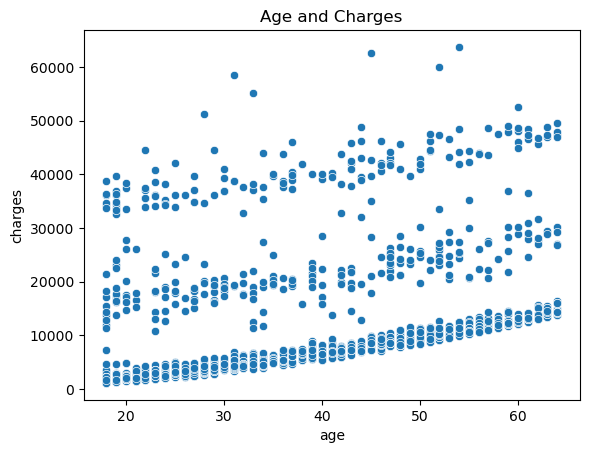

In [55]:
# Scatter Plot of age and charges 

sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age and Charges')
plt.show()

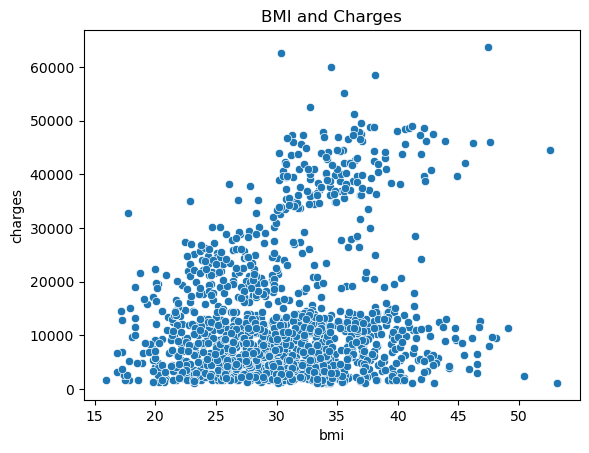

In [56]:
# Scatter Plot of bmi and charges 

sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI and Charges')
plt.show()

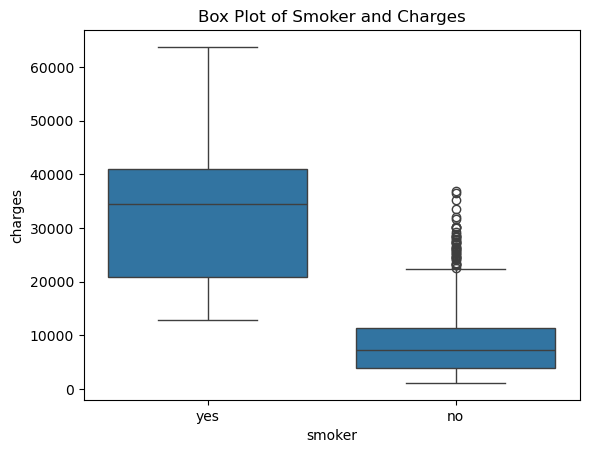

In [58]:
# Exploring Box Plot using Smoker and Charges  

sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Box Plot of Smoker and Charges')
plt.show()

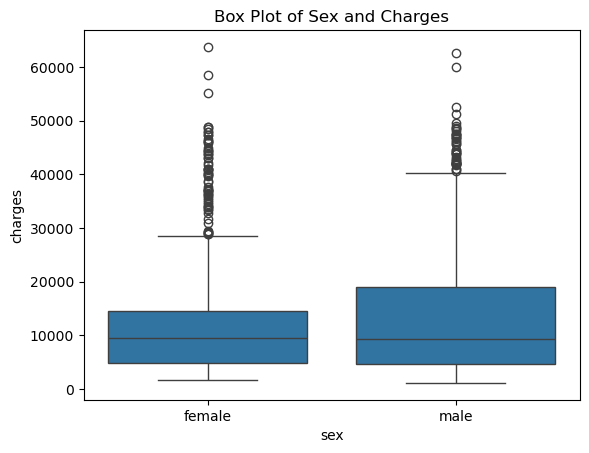

In [59]:
# Exploring Box Plot using Sex and Charges  

sns.boxplot(x='sex', y='charges', data=df)
plt.title('Box Plot of Sex and Charges')
plt.show()

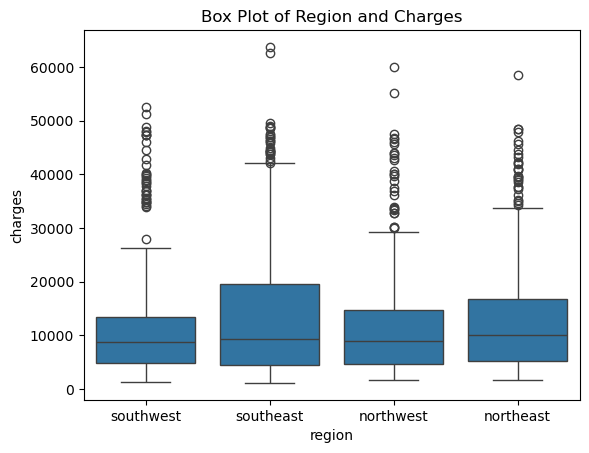

In [60]:
# Exploring Box Plot using Region and Charges  

sns.boxplot(x='region', y='charges', data=df)
plt.title('Box Plot of Region and Charges')
plt.show()

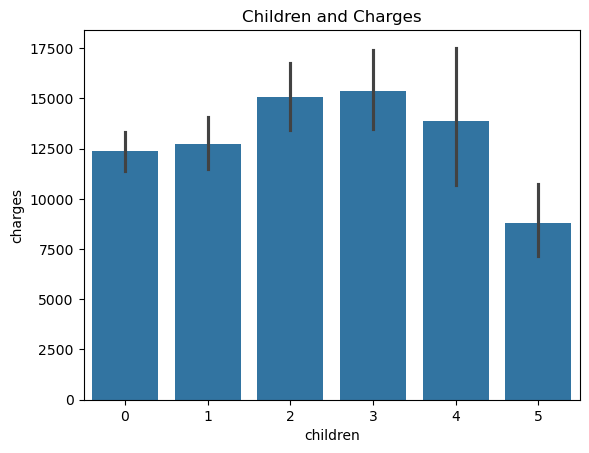

In [62]:
sns.barplot(x='children', y='charges', data=df)
plt.title('Children and Charges')
plt.show()

<Axes: xlabel='sex', ylabel='count'>

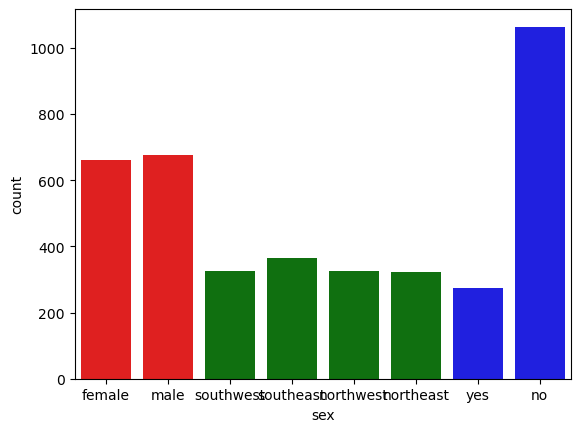

In [69]:
sns.countplot(x='sex', data=df, color='red')
sns.countplot(x='region', data=df, color='green')
sns.countplot(x='smoker', data=df, color='blue')


## Convert Categorical Variables 

In [79]:
df['smoker_encoded'] = df['smoker'].replace({'no' : 0, 'yes' : 1})
print(df['smoker_encoded'])

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker_encoded, Length: 1338, dtype: int64


In [80]:
df['sex_encoded'] = df['sex'].replace({'female' : 1, 'male' : 0})
print(df['sex_encoded'])

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    1
1335    1
1336    1
1337    1
Name: sex_encoded, Length: 1338, dtype: int64


In [ ]:
df['region_encoded'] = df['smoker'].replace({'no' : 0, 'yes' : 1})
print(df['smoker_encoded'])

In [83]:
from sklearn.preprocessing import OneHotEncoder

# categorical_cols = ['southwest', 'southeast',
#                     'northeast', 'northwest']

categorical_cols = ['sex', 'region', 'smoker']
ohe = OneHotEncoder(sparse_output=False)

ohe_array = ohe.fit_transform(df[categorical_cols])
print("OHE feature names:", ohe.get_feature_names_out(categorical_cols))

ohe_df = pd.DataFrame(
    ohe_array, columns=ohe.get_feature_names_out(categorical_cols))
df_ohe = pd.concat([df.reset_index(drop=True), ohe_df], axis=1)
print(df_ohe.head(10))

OHE feature names: ['sex_female' 'sex_male' 'region_northeast' 'region_northwest'
 'region_southeast' 'region_southwest' 'smoker_no' 'smoker_yes']
   age     sex     bmi  ...  region_southwest smoker_no smoker_yes
0   19  female  27.900  ...               1.0       0.0        1.0
1   18    male  33.770  ...               0.0       1.0        0.0
2   28    male  33.000  ...               0.0       1.0        0.0
3   33    male  22.705  ...               0.0       1.0        0.0
4   32    male  28.880  ...               0.0       1.0        0.0
5   31  female  25.740  ...               0.0       1.0        0.0
6   46  female  33.440  ...               0.0       1.0        0.0
7   37  female  27.740  ...               0.0       1.0        0.0
8   37    male  29.830  ...               0.0       1.0        0.0
9   60  female  25.840  ...               0.0       1.0        0.0

[10 rows x 17 columns]
